In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=5,
    noise=10,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["X1", "X2", "X3", "X4", "X5"]
)
df["y"] = y

print(df.info())
print(df.describe())

VX = np.asarray(df[["X1", "X2", "X3", "X4", "X5"]], dtype=np.float32)
Vy = np.asarray(df["y"], dtype=np.float32)

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      100 non-null    float64
 1   X2      100 non-null    float64
 2   X3      100 non-null    float64
 3   X4      100 non-null    float64
 4   X5      100 non-null    float64
 5   y       100 non-null    float64
dtypes: float64(6)
memory usage: 4.8 KB
None
               X1          X2          X3          X4          X5           y
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean    -0.032202    0.128058   -0.044747    0.076954   -0.093874    8.740132
std      1.072806    0.959556    0.900352    0.984110    0.983943  140.222531
min     -2.619745   -1.913280   -1.952088   -2.301921   -3.241267 -345.719886
25%     -0.757046   -0.536288   -0.734897   -0.678136   -0.700307  -76.156948
50%     -0.145714    0.152465   -0.010110    0.066421   -0.024662   11.393220
75%      0.648170    

In [2]:
def hypothesis(Vx, Vw, b):
    return np.dot(Vx, Vw) + b

def cost(Vw, b):
    m = len(VX)
    cost_sum = 0
    for i in range(m):
        Vx = VX[i]
        y = Vy[i]
        y_pred = hypothesis(Vx, Vw, b)
        loss = y_pred - y
        cost_sum += loss ** 2

    return cost_sum / (2 * m)

def compute_gradients(Vw, b, lr):
    m = len(VX)
    dj_dw = np.zeros_like(VX[1])    
    dj_db = 0
    for i in range(m):
        Vx = VX[i]
        y = Vy[i]
        y_pred = hypothesis(Vx, Vw, b)
        loss = y_pred - y
        dj_dw += loss * Vx
        dj_db += loss

    return Vw - ((lr * dj_dw) / m), b - ((lr * dj_db) / m)


iteration 0 9431.48
iteration 100 7804.3433
iteration 200 6475.862


iteration 300 5388.4487
iteration 400 4496.07
iteration 500 3761.8538
iteration 600 3156.2056
iteration 700 2655.325
iteration 800 2240.0303
iteration 900 1894.8303
iteration 1000 1607.1819
iteration 1100 1366.9083
iteration 1200 1165.7305
iteration 1300 996.9009
iteration 1400 854.89966
iteration 1500 735.2054
iteration 1600 634.10474
iteration 1700 548.5394
iteration 1800 475.9814
iteration 1900 414.34454
iteration 2000 361.89407
iteration 2100 317.18567
iteration 2200 279.01733
iteration 2300 246.3836
iteration 2400 218.4433
iteration 2500 194.48946
iteration 2600 173.92818
iteration 2700 156.25743
iteration 2800 141.05418
iteration 2900 127.96034
iteration 3000 116.672295
iteration 3100 106.93182
iteration 3200 98.51944
iteration 3300 91.24814
iteration 3400 84.958435
iteration 3500 79.51369
iteration 3600 74.79725
iteration 3700 70.70918
iteration 3800 67.16359
iteration 3900 64.08673
iteration 4000 61.41513
iteration 4100 59.094418
iteration 4200 57.07738
iteration 4300 55.323563

Text(0.5, 1.0, 'Learning Curve')

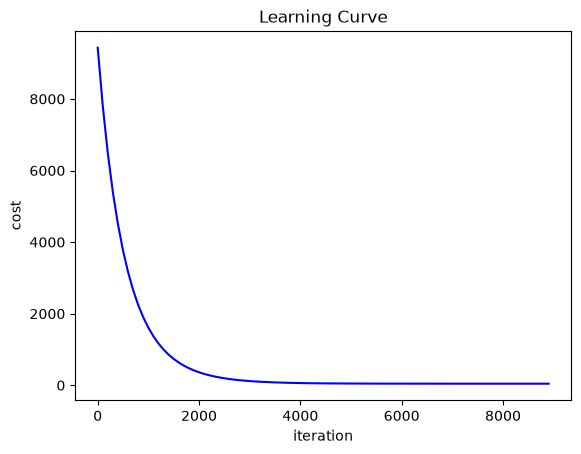

In [3]:
Vw = np.ones_like(VX[0])
b = 10
iteration = 10000
lr = 0.001
initial_cost =  cost(Vw, b)


iter_his = []
cost_his = []

for i in range(iteration):
        new_Vw, new_b = compute_gradients(Vw, b, lr)
        new_cost = cost(new_Vw, new_b)

        if abs(new_cost - initial_cost) < 1e-6:
              break

        if (i % 100 == 0):
            print('iteration', i, new_cost)
            iter_his.append(i)
            cost_his.append(new_cost) 

        initial_cost = new_cost
        Vw, b = new_Vw, new_b

plt.plot(iter_his, cost_his, c='b')
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('Learning Curve')